**https://challengedata.ens.fr/participants/challenges/149/**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sb
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.interpolate import BSpline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

In [ ]:
X_train = pd.read_csv( "C:/Users/lassi/Downloads/train_f_x (1) (1).csv")
Y_train = pd.read_csv("C:/Users/lassi/Downloads/y_train_sncf (1).csv")
X_test = pd.read_csv( "C:/Users/lassi/Downloads/test_f_x_THurtzP (1).csv")
#Y_sample = pd.read_csv('C:/Users/User/Desktop/M2/Datachallenge/y_exemple_sncf_d9so9pm.csv')

**Y_train**

In [3]:
X_train['index']= X_train['date'] +'_'+ X_train['station']
X_train

,date,station,job,ferie,vacances,index
0,2015-01-01,1J7,1,1,1,2015-01-01_1J7
1,2015-01-01,O2O,1,1,1,2015-01-01_O2O
2,2015-01-01,8QR,1,1,1,2015-01-01_8QR
3,2015-01-01,UMC,1,1,1,2015-01-01_UMC
4,2015-01-01,FK3,1,1,1,2015-01-01_FK3
...,...,...,...,...,...,...
1229858,2022-12-31,V2P,0,0,1,2022-12-31_V2P
1229859,2022-12-31,N9K,0,0,1,2022-12-31_N9K
1229860,2022-12-31,P6E,0,0,1,2022-12-31_P6E
1229861,2022-12-31,BDC,0,0,1,2022-12-31_BDC


In [4]:
X_train.isna().sum()
Y_train.isna().sum()

,0
index,0
y,0


In [5]:

data_train = X_train.merge(Y_train,on = 'index')
data_train

,date,station,job,ferie,vacances,index,y
0,2015-01-01,1J7,1,1,1,2015-01-01_1J7,7
1,2015-01-01,O2O,1,1,1,2015-01-01_O2O,0
2,2015-01-01,8QR,1,1,1,2015-01-01_8QR,9
3,2015-01-01,UMC,1,1,1,2015-01-01_UMC,9
4,2015-01-01,FK3,1,1,1,2015-01-01_FK3,28
...,...,...,...,...,...,...,...
1229858,2022-12-31,V2P,0,0,1,2022-12-31_V2P,1227
1229859,2022-12-31,N9K,0,0,1,2022-12-31_N9K,544
1229860,2022-12-31,P6E,0,0,1,2022-12-31_P6E,92
1229861,2022-12-31,BDC,0,0,1,2022-12-31_BDC,91


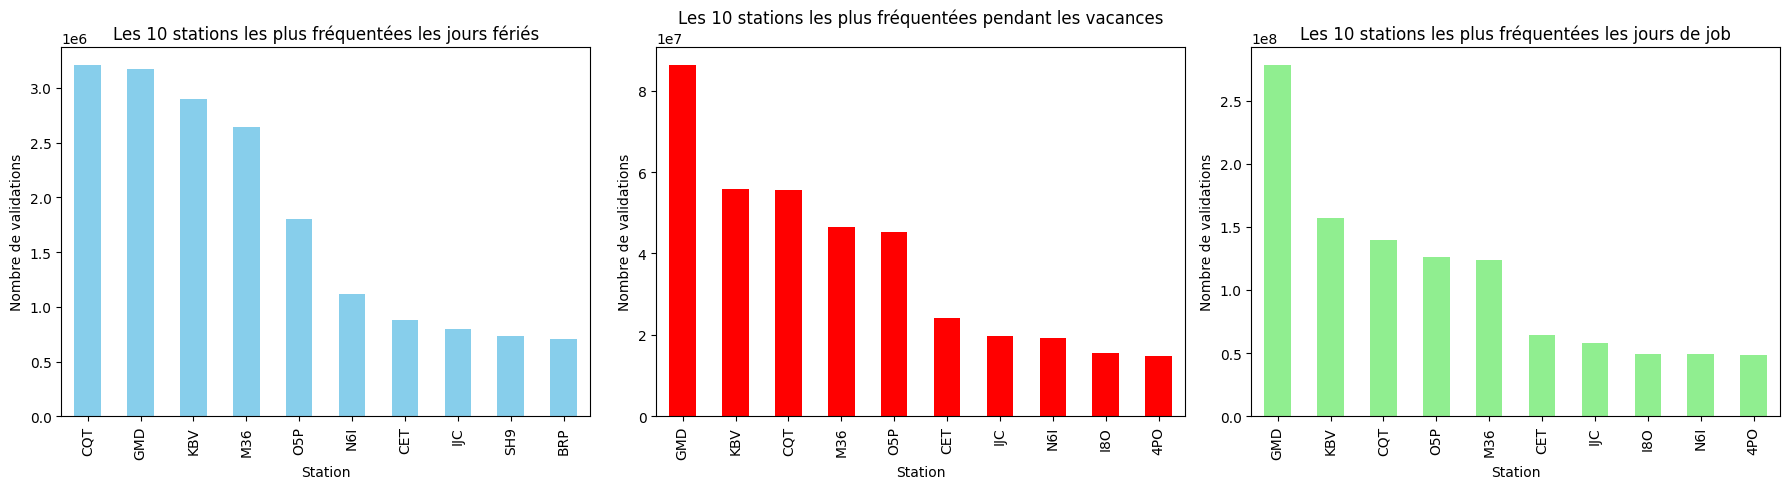

In [6]:

# Filtrer les données
ferie_data = data_train[data_train['ferie'] == 1]
top_10_ferie = ferie_data.groupby('station')['y'].sum().nlargest(10)

vacances_data = data_train[data_train['vacances'] == 1]
top_10_vacances = vacances_data.groupby('station')['y'].sum().nlargest(10)

job_data = data_train[data_train['job'] == 1]
top_10_job = job_data.groupby('station')['y'].sum().nlargest(10)


plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 3)
top_10_job.plot(kind='bar', color='lightgreen')
plt.title('Les 10 stations les plus fréquentées les jours de job')
plt.xlabel('Station')
plt.ylabel('Nombre de validations')


plt.subplot(1, 3, 1)
top_10_ferie.plot(kind='bar', color='skyblue')
plt.title('Les 10 stations les plus fréquentées les jours fériés')
plt.xlabel('Station')
plt.ylabel('Nombre de validations')


plt.subplot(1, 3, 2)
top_10_vacances.plot(kind='bar', color='red')
plt.title('Les 10 stations les plus fréquentées pendant les vacances')
plt.xlabel('Station')
plt.ylabel('Nombre de validations')


plt.tight_layout()
plt.show()

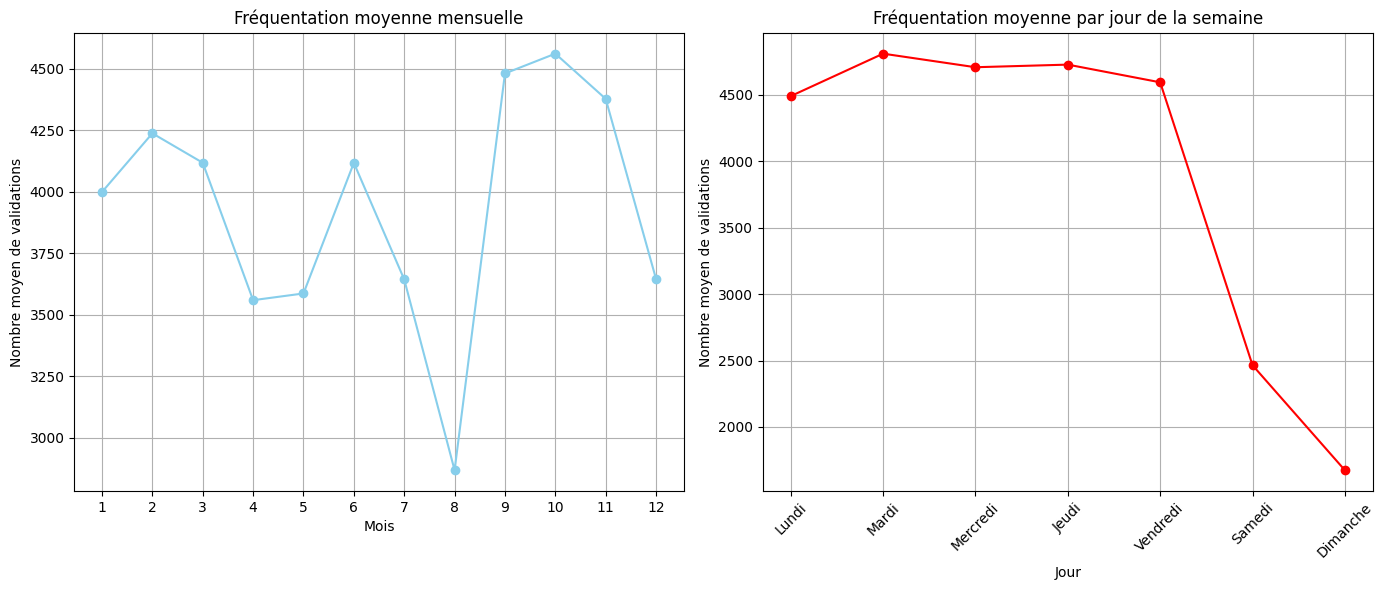

In [7]:

# Assurez-vous que la colonne 'date' est bien de type datetime
data_train['date'] = pd.to_datetime(data_train['date'])

data_train['mois'] = data_train['date'].dt.month
data_train['jour'] = data_train['date'].dt.day_name()

# Créer un dictionnaire pour mapper les jours de la semaine en anglais aux jours en français
jours_traduction = {
    'Monday': 'Lundi',
    'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi',
    'Thursday': 'Jeudi',
    'Friday': 'Vendredi',
    'Saturday': 'Samedi',
    'Sunday': 'Dimanche'
}

data_train['jour'] = data_train['jour'].map(jours_traduction)

data_mensuelles = data_train.groupby('mois')['y'].mean()

data_journalières = data_train.groupby('jour')['y'].mean()

ordre_jours_semaine = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
data_journalières = data_journalières.reindex(ordre_jours_semaine)

plt.figure(figsize=(14, 6))

# Graphique combiné : tendance mensuelle et hebdomadaire
plt.subplot(1, 2, 1)
plt.plot(data_mensuelles.index, data_mensuelles.values, marker='o', linestyle='-', color='skyblue')
plt.title('Fréquentation moyenne mensuelle')
plt.xlabel('Mois')
plt.ylabel('Nombre moyen de validations')
plt.grid(True)
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
plt.plot(data_journalières.index, data_journalières.values, marker='o', linestyle='-', color='red')
plt.title('Fréquentation moyenne par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Nombre moyen de validations')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Distribution de y**

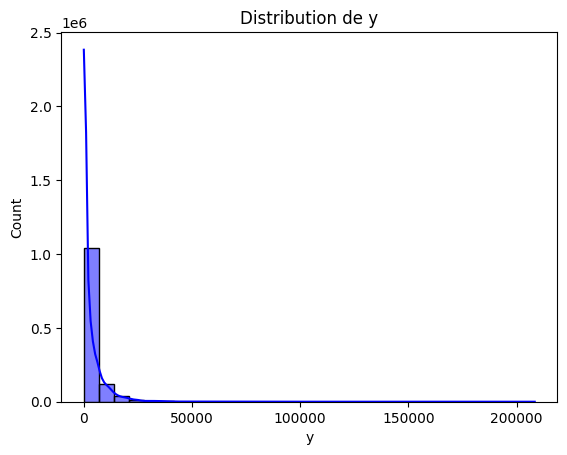

In [8]:

sns.histplot(data_train['y'], kde=True, bins=30, color='blue')
plt.title("Distribution de y")
plt.xlabel("y")
plt.show()

**Gares retirée et ajoutée**

In [9]:



data_train['date'] = pd.to_datetime(data_train['date'],format='%Y-%m-%d')
data_train['annee'] = data_train['date'].dt.year
gares_par_annee = data_train.groupby('annee')['station'].unique()


gares_par_annee_dict = gares_par_annee.to_dict()

gares_disparues = {}
gares_ajoutees = {}

# Comparer les gares d'une année à l'autre
for annee in sorted(gares_par_annee_dict.keys())[:-1]:
    gares_annee_courante = set(gares_par_annee_dict[annee])
    gares_annee_suivante = set(gares_par_annee_dict[annee + 1])

    # Gares disparues
    disparues_cette_annee = gares_annee_courante - gares_annee_suivante
    for gare in disparues_cette_annee:
        if gare not in gares_disparues:
            gares_disparues[gare] = annee

    # Gares ajoutées
    ajoutees_cette_annee = gares_annee_suivante - gares_annee_courante
    for gare in ajoutees_cette_annee:
        if gare not in gares_ajoutees:
            gares_ajoutees[gare] = annee + 1


print("Gares disparues avec leur année de disparition :")
for gare, annee in gares_disparues.items():
    print(f"{gare}: {annee}")

print("\nGares ajoutées avec leur année d'ajout :")
for gare, annee in gares_ajoutees.items():
    print(f"{gare}: {annee}")


Gares disparues avec leur année de disparition :
52H: 2017
EFN: 2019
L58: 2019
TPX: 2019
B9M: 2019
92P: 2019

Gares ajoutées avec leur année d'ajout :
N9K: 2017
OWM: 2017
V2P: 2017
48S: 2017
52H: 2019
EFN: 2022
QD6: 2022
BDC: 2022
W14: 2022
TPX: 2022
L58: 2022
B9M: 2022
W80: 2022
92P: 2022
P6E: 2022


**Prétraitement**

In [10]:
from sklearn.preprocessing import LabelEncoder
X_train['index']= X_train['date'] +'_'+ X_train['station']
index_test=X_test['index']
data_train = X_train.merge(Y_train,on = 'index')
d_train = data_train

# numeroté les stations
label_encoder = LabelEncoder()
d_train['station'] = label_encoder.fit_transform(d_train['station'])
X_test['station'] = label_encoder.transform(X_test['station'])

#X_test['station2'] = label_encoder.transform(X_test['station'])
df_train= d_train.drop(columns=['index']) # sans l'index
df_test= X_test.drop(columns=['index']) # sans l'index


# Conversion explicite de la colonne "date" en chaînes de caractères
df_train['date'] = df_train['date'].astype(str)
df_test['date'] = df_test['date'].astype(str)

# Suppression des tirets
df_train['date'] = df_train['date'].str.replace("-", "", regex=False)
df_test['date'] = df_test['date'].str.replace("-", "", regex=False)


df_train['y_log'] = np.log1p(df_train['y'])  # log(1 + y) pour éviter log(0)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_train.drop(columns=['y','y_log'])
y = df_train['y_log']


# Fonction pour exporter les données sur le site datachallenge
def export(predictions, index_test, filename='predictions.csv'):

    predictions_df = pd.DataFrame({'index': index_test, 'y': predictions})


    predictions_df.to_csv(filename, index=False, sep=',')
    print(f"Predictions exported to {filename} with delimiter ','")

**MODELES**

In [26]:


# modèles
models = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=42),
    "ExtraTreeRegressor": ExtraTreeRegressor(random_state=42),
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "BaggingRegressor": BaggingRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)  # Nouveau modèle ajouté
}

# Entraînement et prédiction pour chaque modèle
predictions = {}
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(df_test)
    predictions[name] = y_pred
    print(f"{name}: Prédiction sur X_test = {y_pred[:5]}")

ExtraTreesRegressor: Prédiction sur X_test = [3.63910588 3.08785792 3.25998355 1.79175947 3.63758616]
ExtraTreeRegressor: Prédiction sur X_test = [3.63758616 3.09104245 3.25809654 1.79175947 3.63758616]
LinearRegression: Prédiction sur X_test = [4.70646087 5.1132794  4.83105842 5.07424884 5.22136403]
RidgeRegression: Prédiction sur X_test = [4.70649025 5.11330878 4.83108781 5.07427822 5.22139341]
DecisionTreeRegressor: Prédiction sur X_test = [3.63758616 3.09104245 3.29583687 1.79175947 3.63758616]
RandomForestRegressor: Prédiction sur X_test = [3.60465333 2.94067664 3.24590586 1.88267984 3.69915566]
BaggingRegressor: Prédiction sur X_test = [3.56869335 2.86293936 3.24712309 1.91298663 3.7028953 ]
GradientBoostingRegressor: Prédiction sur X_test = [5.23804033 5.68184293 5.87107997 5.37698526 6.04049333]


In [12]:

# reseau neurone
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_percentage_error

# Convertir y en tableau NumPy (si nécessaire)
if isinstance(y, pd.Series):
    y = y.to_numpy()

# Normalisation des données
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Définir le modèle
model = Sequential([
    Dense(64, input_dim=X.shape[1], activation='relu'),  # Couche d'entrée
    Dense(32, activation='relu'),                       # Couche cachée
    Dense(1, activation='linear')                       # Couche de sortie
])

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Entraîner le modèle
history = model.fit(
    X_scaled, y_scaled,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Normaliser X_test
X_test_scaled = scaler_X.transform(df_test)

# Faire des prédictions
y_pred_scaled = model.predict(X_test_scaled)

# Inverser la normalisation pour obtenir les valeurs réelles
y_pred = scaler_y.inverse_transform(y_pred_scaled)


print("Prédictions sur le jeu de test :")
print(y_pred[:5])

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38434/38434 ━━━━━━━━━━━━━━━━━━━━ 76s 2ms/step - loss: 0.9164 - mae: 0.7873
Epoch 2/5
38434/38434 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 0.9047 - mae: 0.7812
Epoch 3/5
38434/38434 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - loss: 0.9003 - mae: 0.7773
Epoch 4/5
38434/38434 ━━━━━━━━━━━━━━━━━━━━ 70s 2ms/step - loss: 0.8956 - mae: 0.7739
Epoch 5/5
38434/38434 ━━━━━━━━━━━━━━━━━━━━ 68s 2ms/step - loss: 0.8942 - mae: 0.7722
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Prédictions sur le jeu de test :
[[5.625492 ]
 [6.1893497]
 [6.0282307]
 [6.169959 ]
 [6.247565 ]]


**Recherche meilleur paramètre et validation croisée**

In [13]:
from sklearn.tree import ExtraTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Grille élargie d'hyperparamètres
param_dist = {
    "criterion": ["squared_error", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2", 0.8],  # Ajout de fractions pour max_features
}

# Initialisation du modèle
extra_tree = ExtraTreeRegressor(random_state=42)

# Configuration de RandomizedSearchCV avec validation croisée à 5 folds
random_search = RandomizedSearchCV(
    estimator=extra_tree,
    param_distributions=param_dist,
    n_iter=100,  # pour couvrir plus de combinaisons
    scoring="neg_mean_squared_error",
    cv=5,  # 5-folds pour une validation croisée plus robuste
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Entraînement du modèle avec RandomizedSearchCV
random_search.fit(X, y)

# Meilleurs paramètres trouvés
best_params = random_search.best_params_
print("Meilleurs paramètres trouvés :", best_params)

# Meilleur modèle
best_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


KeyboardInterrupt: 

In [ ]:
# Validation croisée supplémentaire sur le meilleur modèle
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')

# Moyenne et écart type des scores de validation croisée
print(f"Scores de validation croisée : {cv_scores}")
print(f"Moyenne des scores : {cv_scores.mean()}")
print(f"Écart-type des scores : {cv_scores.std()}")

In [ ]:
# Prédiction avec le meilleur modèle sur le jeu de test
y_pred_actual = np.expm1(y_pred)  # Inverser la transformation du log

print(f"Prédictions sur le jeu de test: {y_pred_actual[:5]}")

**Approche de Resolution par les données fonctionnelles**

In [1]:
!pip install scikit-learn-extra
!pip install scipy
!pip install scikit-fda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.4 MB/s eta 0:00:00


**Analyse préliminaire des données : visualisation et validation des objectifs**

In [6]:
if 'date' not in train_y.columns or 'station' not in train_y.columns:
    train_y[['date', 'station']] = train_y['index'].str.split('_', expand=True)
    train_y = train_y.drop(columns=['index'])

train_y = train_y.rename(columns={'y': 'nombre de validation'})
print(train_y)
print(train_x)

         nombre de validation        date station
0                           7  2015-01-01     1J7
1                           0  2015-01-01     O2O
2                           9  2015-01-01     8QR
3                           9  2015-01-01     UMC
4                          28  2015-01-01     FK3
...                       ...         ...     ...
1229858                  1227  2022-12-31     V2P
1229859                   544  2022-12-31     N9K
1229860                    92  2022-12-31     P6E
1229861                    91  2022-12-31     BDC
1229862                    18  2022-12-31     W14

[1229863 rows x 3 columns]
               date station  job  ferie  vacances
0        2015-01-01     1J7    1      1         1
1        2015-01-01     O2O    1      1         1
2        2015-01-01     8QR    1      1         1
3        2015-01-01     UMC    1      1         1
4        2015-01-01     FK3    1      1         1
...             ...     ...  ...    ...       ...
1229858  2022-12-31   

In [ ]:
data_path = "C:/Users/lassi/Downloads/train_f_x (1) (1).csv"
train_x = pd.read_csv(data_path, header=0, sep=',')

data_path = "C:/Users/lassi/Downloads/y_train_sncf (1).csv"

train_y = pd.read_csv(data_path)

if 'date' not in train_y.columns or 'station' not in train_y.columns:
    train_y[['date', 'station']] = train_y['index'].str.split('_', expand=True)
    train_y = train_y.drop(columns=['index'])

train_y = train_y.rename(columns={'y': 'nombre de validation'})
print(train_y)
print(train_x)

         nombre de validation        date station
0                           7  2015-01-01     1J7
1                           0  2015-01-01     O2O
2                           9  2015-01-01     8QR
3                           9  2015-01-01     UMC
4                          28  2015-01-01     FK3
...                       ...         ...     ...
1229858                  1227  2022-12-31     V2P
1229859                   544  2022-12-31     N9K
1229860                    92  2022-12-31     P6E
1229861                    91  2022-12-31     BDC
1229862                    18  2022-12-31     W14

[1229863 rows x 3 columns]
               date station  job  ferie  vacances
0        2015-01-01     1J7    1      1         1
1        2015-01-01     O2O    1      1         1
2        2015-01-01     8QR    1      1         1
3        2015-01-01     UMC    1      1         1
4        2015-01-01     FK3    1      1         1
...             ...     ...  ...    ...       ...
1229858  2022-12-31   

**Concatenation**

In [7]:
train_merged = pd.merge(train_x, train_y, on=['date', 'station'], how='inner')
print(train_merged)

               date station  job  ferie  vacances  nombre de validation
0        2015-01-01     1J7    1      1         1                     7
1        2015-01-01     O2O    1      1         1                     0
2        2015-01-01     8QR    1      1         1                     9
3        2015-01-01     UMC    1      1         1                     9
4        2015-01-01     FK3    1      1         1                    28
...             ...     ...  ...    ...       ...                   ...
1229858  2022-12-31     V2P    0      0         1                  1227
1229859  2022-12-31     N9K    0      0         1                   544
1229860  2022-12-31     P6E    0      0         1                    92
1229861  2022-12-31     BDC    0      0         1                    91
1229862  2022-12-31     W14    0      0         1                    18

[1229863 rows x 6 columns]


In [8]:
train_merged['date'] = pd.to_datetime(train_merged['date'])

In [9]:

train_merged['month'] = train_merged['date'].dt.month
train_merged['day'] = train_merged['date'].dt.day

daily_average = train_merged.groupby(['station', 'month', 'day'])['nombre de validation'].mean().reset_index()
daily_average = daily_average.rename(columns={'nombre de validation': 'daily_average_validations'})

train_merged = pd.merge(train_merged, daily_average, on=['station', 'month', 'day'], how='left')

# train_merged = train_merged.drop(columns=['month', 'day'])

In [10]:

train_merged = train_merged.sort_values(by=['station', 'date'])
grouped = train_merged.groupby('station')
stations = train_merged['station'].unique()
train_merged['nombre de validation'] = np.log1p(train_merged['nombre de validation'])


In [11]:
print(f"Taille de train_x : {train_x.shape}")
print(f"Taille de train_y : {train_y.shape}")
print(f"Taille de train_merged : {train_merged.shape}")


Taille de train_x : (1229863, 5)
Taille de train_y : (1229863, 3)
Taille de train_merged : (1229863, 9)


**Base de données fonctionnelles choix de bases**

<ipython-input-12-e60dd067baea>:13: DeprecationWarning: The Fourier class is deprecated. Use FourierBasis instead.
  fourier_basis = Fourier(n_basis=21, domain_range=(0, 365))
<ipython-input-12-e60dd067baea>:32: DeprecationWarning: The BSpline class is deprecated. Use BSplineBasis instead.
  bspline_basis = BSpline(n_basis=21, domain_range=(0, 365))


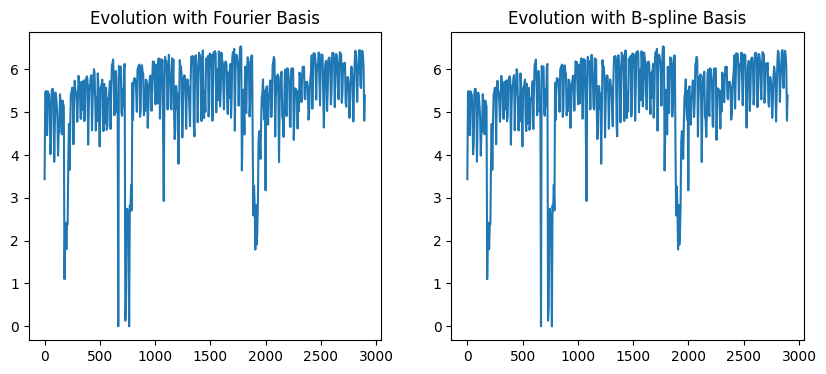

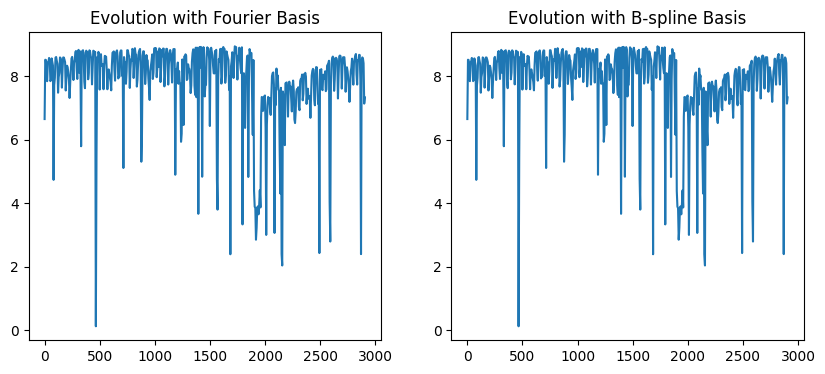

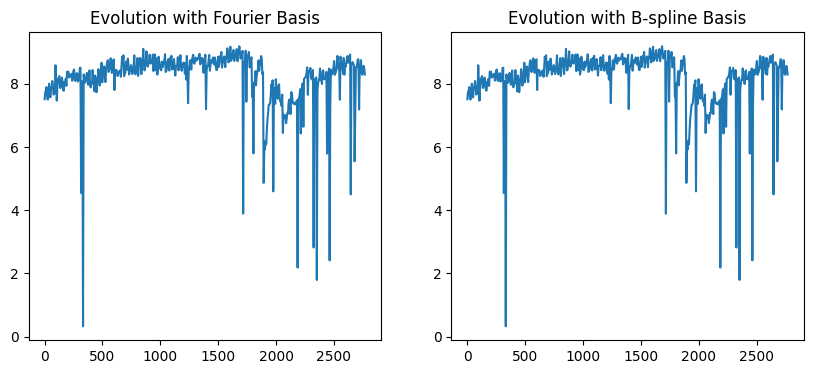

In [12]:

from skfda.representation.basis import Fourier, BSpline
from skfda.representation.grid import FDataGrid


train_merged['date'] = pd.to_datetime(train_merged['date'])
train_merged = train_merged.sort_values(by=['station', 'date'])


grouped = train_merged.groupby('station')
stations = train_merged['station'].unique()

#fourier
fourier_basis = Fourier(n_basis=21, domain_range=(0, 365))


fd_fourier_list = []
for i, (station, group) in enumerate(grouped):
    y = group['nombre de validation'].values


    x = np.arange(len(group))


    fd = FDataGrid(data_matrix=y, grid_points=x)


    fd.basis = fourier_basis

    fd_fourier_list.append(fd)

#  B-spline basis
bspline_basis = BSpline(n_basis=21, domain_range=(0, 365))


fd_bspline_list = []
for i, (station, group) in enumerate(grouped):
    y = group['nombre de validation'].values


    x = np.arange(len(group))


    fd = FDataGrid(data_matrix=y, grid_points=x)


    fd.basis = bspline_basis

    fd_bspline_list.append(fd)


for i in range(min(3, len(fd_fourier_list))):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    fd_fourier_list[i].plot(axes[0], label=f'Station {stations[i]} (Fourier)')
    fd_bspline_list[i].plot(axes[1], label=f'Station {stations[i]} (B-spline)')

    axes[0].set_title('Evolution with Fourier Basis')
    axes[1].set_title('Evolution with B-spline Basis')

    plt.show()

**on visualise s'elle modelise bien les courbes**

<ipython-input-14-fab35e503c3e>:7: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  fourier_pred = fd_fourier_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()


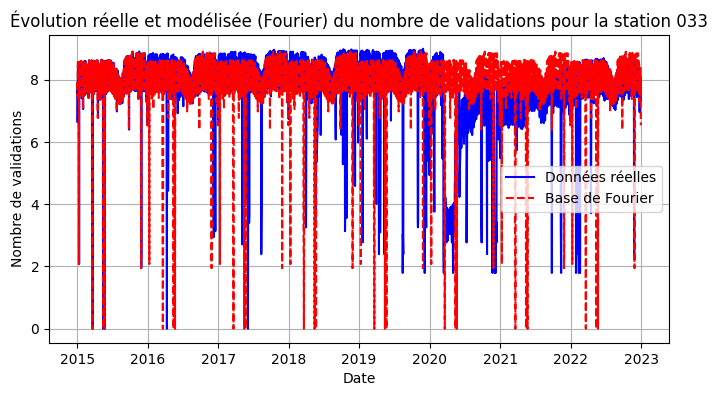

In [14]:

station_index = 1

station_data = train_merged[train_merged['station'] == stations[station_index]]
dates = station_data['date']
validations = station_data['nombre de validation']
original_x = station_data['date'].dt.dayofyear.values
fourier_pred = fd_fourier_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()
plt.figure(figsize=(8, 4))
plt.plot(dates, validations, label='Données réelles', color='blue')
plt.plot(dates, fourier_pred, label='Base de Fourier', color='red', linestyle='--')
plt.title(f"Évolution réelle et modélisée (Fourier) du nombre de validations pour la station {stations[station_index]}")
plt.xlabel('Date')
plt.ylabel('Nombre de validations')
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-15-2b54bb25f091>:10: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  fourier_pred = fd_fourier_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()
<ipython-input-15-2b54bb25f091>:11: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  bspline_pred = fd_bspline_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()


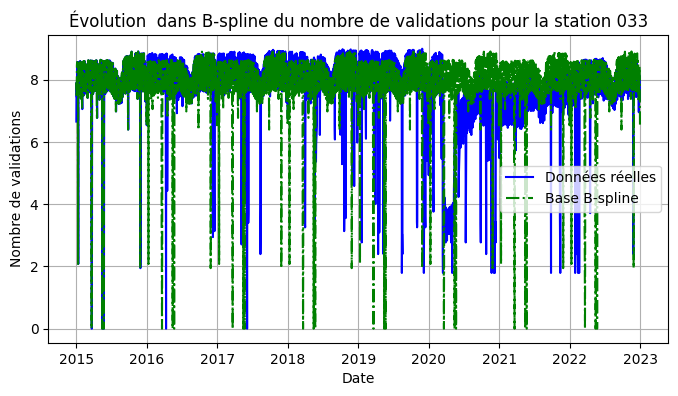

In [15]:

station_index = 1


station_data = train_merged[train_merged['station'] == stations[station_index]]

dates = station_data['date']
validations = station_data['nombre de validation']

original_x = station_data['date'].dt.dayofyear.values
fourier_pred = fd_fourier_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()
bspline_pred = fd_bspline_list[station_index].evaluate(original_x.reshape(-1, 1)).squeeze()

plt.figure(figsize=(8, 4))
plt.plot(dates, validations, label='Données réelles', color='blue')
plt.plot(dates, bspline_pred, label='Base B-spline', color='green', linestyle='-.')
plt.title(f"Évolution  dans B-spline du nombre de validations pour la station {stations[station_index]}")
plt.xlabel('Date')
plt.ylabel('Nombre de validations')
plt.legend()
plt.grid(True)

In [ ]:
file_id = "C:/Users/lassi/Downloads/test_f_x_THurtzP (1).csv"

test_x = pd.read_csv(file_id, header=0, sep=',')



In [13]:

test_x['date'] = pd.to_datetime(test_x['date'])

test_x['month'] = test_x['date'].dt.month
test_x['day'] = test_x['date'].dt.day

In [14]:
test_stations = test_x['station'].unique()

In [15]:
train_merged['day_of_week'] = pd.to_datetime(train_merged['date']).dt.dayofweek + 1

**Insertions des coordonnées des bases dans les données pour remplacer le nombre de validation**

In [16]:
from skfda import FDataGrid

fourier_coeffs = [fd.data_matrix.flatten() for fd in fd_fourier_list]

bspline_coeffs = [fd.data_matrix.flatten() for fd in fd_bspline_list]
max_len = max(len(arr) for arr in fourier_coeffs)
fourier_coeffs_padded = [np.pad(arr, (0, max_len - len(arr)), 'constant') for arr in fourier_coeffs]
bspline_coeffs_padded = [np.pad(arr, (0, max_len - len(arr)), 'constant') for arr in bspline_coeffs]

X_fourier = np.array(fourier_coeffs_padded)
X_bspline = np.array(bspline_coeffs_padded)

In [17]:
fourier_cols = [f'fourier_coeff_{i}' for i in range(fourier_basis.n_basis)]
bspline_cols = [f'bspline_coeff_{i}' for i in range(bspline_basis.n_basis)]
for i, station in enumerate(stations):
    train_merged.loc[train_merged['station'] == station, fourier_cols] = fourier_coeffs[i][0]

    train_merged.loc[train_merged['station'] == station, bspline_cols] = bspline_coeffs[i][0]

**Les modeles auront pour vocation de predire les coefficients de ces bases pour enfin les representer et extraire les pics**

In [18]:
X = train_merged[['job','ferie','vacances','month']]
y_fourier = train_merged[[f'fourier_coeff_{i}' for i in range(fourier_basis.n_basis)]]

In [19]:
X_train, X_val, y_fourier_train, y_fourier_val = train_test_split(X, y_fourier, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


fourier_model = LinearRegression()
fourier_model.fit(X_train, y_fourier_train)

#bspline_model = LinearRegression()
#bspline_model.fit(X_train, y_bspline_train)

LinearRegression()

In [43]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline

#Regression ridge
fourier_model = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))

# model
fourier_model.fit(X_train, y_fourier_train)
#bspline_model.fit(X_train, y_bspline_train)

param_grid = {
    'polynomialfeatures__degree': [1, 2, 3],
    'ridge__alpha': [0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(fourier_model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_fourier_train)

best_fourier_model = grid_search.best_estimator_


In [44]:
from sklearn.linear_model import LinearRegression

test_data = test_x[['job', 'ferie', 'vacances','month']]

test_data = test_data.astype(int)

predicted_fourier_coeffs = best_fourier_model.predict(test_data)

#predicted_bspline_coeffs = best_bspline_model.predict(test_data)


In [20]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split


#  Bagging Regressor models for Fourier coefficients
fourier_bagging_models = []
for i in range(y_fourier_train.shape[1]):
    bagging_model = BaggingRegressor(random_state=42)
    bagging_model.fit(X_train, y_fourier_train.iloc[:, i])
    fourier_bagging_models.append(bagging_model)



predicted_fourier_coeffs = [model.predict(test_x[['job', 'ferie', 'vacances','month']]) for model in fourier_bagging_models]




In [21]:
from skfda.representation.basis import FourierBasis, FDataBasis
#1 Bagging tree  et regression

predicted_fourier_coeffs = np.array(predicted_fourier_coeffs).T

if predicted_fourier_coeffs.shape[1] > fourier_basis.n_basis:
    predicted_fourier_coeffs = predicted_fourier_coeffs[:, :fourier_basis.n_basis]

fd_reconstructed = FDataBasis(basis=fourier_basis, coefficients=predicted_fourier_coeffs)


days = np.linspace(0, 180, 181)
#reconstructed_values = fd_reconstructed.evaluate(days)
reconstructed_values = fd_reconstructed(days)



In [22]:
from skfda.representation.basis import FourierBasis, FDataBasis

#2
reconstructed_values = fd_reconstructed.evaluate(days)

stations = test_x['station'].unique()
station_mapping = {station: i for i, station in enumerate(stations)}

test_x['nombre de validation'] = 0

for index, row in test_x.iterrows():
    station_idx = station_mapping.get(row['station'])

    if station_idx is not None and station_idx < reconstructed_values.shape[0]:
        day_idx = row['day'] - 1
        if 0 <= day_idx < reconstructed_values.shape[1]:
            test_x.loc[index, 'nombre de validation'] = reconstructed_values[station_idx, day_idx, 0]


<ipython-input-22-0bf21c35ffae>:4: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  reconstructed_values = fd_reconstructed.evaluate(days)
<ipython-input-22-0bf21c35ffae>:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.827032771951547' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_x.loc[index, 'nombre de validation'] = reconstructed_values[station_idx, day_idx, 0]


**Echelle initiale**

In [24]:
test_x['nombre de validation'] = np.expm1(test_x['nombre de validation'])#5

In [25]:
test_x= test_x[['index', 'nombre de validation']]#6
print(test_x)

                index  nombre de validation
0      2023-01-01_1J7             44.926063
1      2023-01-01_O2O             44.926063
2      2023-01-01_8QR             44.926063
3      2023-01-01_L58             44.926063
4      2023-01-01_UMC             44.926063
...               ...                   ...
78647  2023-05-31_N9K             -0.210430
78648  2023-05-31_P6E             -0.210430
78649  2023-05-31_BDC             -0.210430
78650  2023-05-31_QD6             -0.209341
78651  2023-05-31_W14             -0.210430

[78652 rows x 2 columns]


**les predictions negatives seront senssible à 0**

In [27]:
test_x['nombre de validation'] = test_x['nombre de validation'].clip(lower=0)#7

In [34]:
from IPython.display import FileLink
test_x.to_csv('submission.csv', index=False)
FileLink('submission.csv')


/content/submission.csv